# Graph divergence: pairwise comparison of all retweet graphs

For graph-transfer analysis we want to know **how the source/target retweet graphs
differ**. Rather than one blended similarity score, we diagnose three axes separately
and then measure the coupling that message passing actually transfers:

1. **Topology** — degree distributions (directed: in/out), density, reciprocity,
   degree assortativity, clustering, largest WCC/SCC.
2. **Features** — GTE bio embeddings: missing-bio rate, effective dimensionality,
   and pairwise cloud divergence (centroid cosine, Frechet, RBF-MMD²,
   proxy-A-distance).
3. **Feature–structure coupling** — edge feature homophily vs. a random-pair
   baseline, Dirichlet energy, and, where labels exist, raw edge homophily,
   directed endpoint-marginal expected agreement, and Newman assortativity.

Data: `graph_divergence_data.json`, produced by
`scripts/experiments/analysis/graphs/structure/graph_divergence/compute_graph_divergence.py` on Tucker
(see that folder's README). All per-graph feature stats are on non-missing-bio
nodes; the missing-bio rate is reported separately as a first-order confound.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data/graph_divergence_data.json")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
blob = json.load(open(DATA))
GRAPHS = blob["graphs"]
PG = blob["per_graph"]
PW = blob["pairwise"]
print("generated:", blob["meta"]["generated_at"], "| commit:", blob["meta"]["git_commit"])
print("config:", blob["meta"]["config"])
print(f"{len(GRAPHS)} graphs:", GRAPHS)

generated: 2026-08-12 12:46:06 | commit: 2bd0654bc1524f4208cca82e678351e4ddf7f67b
config: {'feat_sample': 4000, 'edge_sample': 300000, 'max_edges_exact': 40000000, 'clustering_nodes': 3000, 'mmd_cap': 1000}
9 graphs: ['covid19_twitter', 'ukr_rus_twitter', 'midterm', 'cp_hk_twitter', 'twibot20', 'election2020', 'covid_political', 'ukr_rus_suspended', 'facebook_page_reference']


## 1. Per-graph summary table

One row per graph. `missing_bio_rate` and `edge_bio_coverage` frame every feature
number below — a graph with many empty bios has less feature signal to transfer.

In [2]:
SUMMARY_COLS = [
    "n_nodes", "n_edges", "density", "reciprocity", "degree_assortativity",
    "in_degree_gini", "out_degree_gini", "avg_clustering_approx",
    "largest_wcc_frac", "largest_scc_frac", "isolated_fraction",
    "missing_bio_rate", "feature_effective_dim", "feature_norm_mean",
    "sampled_edge_count", "feature_edge_count", "feature_random_pair_count",
    "feature_homophily", "feature_homophily_random", "dirichlet_energy",
    "has_labels", "labeled_edge_count", "labeled_edge_fraction",
    "label_homophily", "label_homophily_expected", "label_assortativity_newman",
]
summary = pd.DataFrame(
    {g: {c: PG[g].get(c) for c in SUMMARY_COLS} for g in GRAPHS}
).T[SUMMARY_COLS]
# feature homophily lift over random baseline (how much edges align features)
summary["homophily_lift"] = summary["feature_homophily"] - summary["feature_homophily_random"]
summary.to_csv(DATA.parent / "per_graph_summary.csv")
label_rows = []
for g in GRAPHS:
    mixing = PG[g].get("label_mixing")
    if not mixing:
        continue
    names = PG[g].get("label_names", [])
    for label in mixing["classes"]:
        key = str(label)
        label_rows.append({
            "graph": g, "label": label,
            "label_name": names[label] if 0 <= label < len(names) else key,
            "source_endpoint_count": mixing["source_endpoint_counts"][key],
            "destination_endpoint_count": mixing["destination_endpoint_counts"][key],
            "same_label_rate_by_source_class": mixing["same_label_rate_by_source_class"][key],
            "same_label_rate_by_destination_class": mixing["same_label_rate_by_destination_class"][key],
        })
pd.DataFrame(label_rows).to_csv(DATA.parent / "per_class_label_mixing.csv", index=False)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
summary

,n_nodes,n_edges,density,reciprocity,degree_assortativity,in_degree_gini,out_degree_gini,avg_clustering_approx,largest_wcc_frac,largest_scc_frac,...,feature_homophily,feature_homophily_random,dirichlet_energy,has_labels,labeled_edge_count,labeled_edge_fraction,label_homophily,label_homophily_expected,label_assortativity_newman,homophily_lift
covid19_twitter,23012850,107222182,2.025e-07,0.002598,-0.01715,0.9843,0.7118,0.03342,0.969,0.05591,...,0.5472,0.5067,0.9057,False,0,None,None,None,None,0.04044
ukr_rus_twitter,10400775,76851913,7.104e-07,0.002881,-0.05684,0.9897,0.7923,0.047,0.9806,0.06355,...,0.5388,0.5126,0.9224,False,0,None,None,None,None,0.02619
midterm,341908,899979,7.699e-06,0.008542,-0.0957,0.9847,0.5812,0.03661,0.9257,0.01876,...,0.5793,0.549,0.8414,False,0,None,None,None,None,0.03027
cp_hk_twitter,333800,1184379,1.063e-05,0.002226,-0.228,0.9979,0.7145,0.0987,0.8825,0.01158,...,0.5534,0.501,0.8931,False,0,None,None,None,None,0.05247
twibot20,162990,2010925,7.57e-05,0.01751,0.1866,0.9384,0.6123,0.06019,0.9851,0.1798,...,0.5778,0.508,0.8444,True,4949,0.0165,0.4015,0.3717,0.04746,0.06974
election2020,78932,2818603,0.0004524,0,-0.1905,0.5429,0.9635,0.2133,0.9999,1.267e-05,...,0.6069,0.5915,0.7862,True,300000,1,0.9515,0.5206,0.8989,0.01535
covid_political,78672,180928,2.923e-05,0,-0.1956,0.7051,0.9912,0.06054,0.6605,1.271e-05,...,0.5766,0.5496,0.8468,True,180928,1,0.9355,0.5178,0.8663,0.02701
ukr_rus_suspended,72295,354209,6.777e-05,0.08879,-0.1209,0.9376,0.7227,0.09641,0.7611,0.2114,...,0.5629,0.5114,0.8742,True,222206,0.7407,0.5538,0.5522,0.003534,0.05149
facebook_page_reference,119228,167622,1.179e-05,0.01697,0.1431,0.8627,0.5941,0.04083,0.6615,0.006249,...,0.5677,0.4909,0.8646,True,95793,0.5715,0.2169,0.05855,0.1682,0.07674


## 2. Pairwise divergence heatmaps

Every panel is a graph×graph matrix. Higher = more different. `proxy_a_distance`
is a domain classifier's separability of the two feature clouds (0 = indistinguishable,
2 = perfectly separable); the KS panels compare in/out degree distributions.

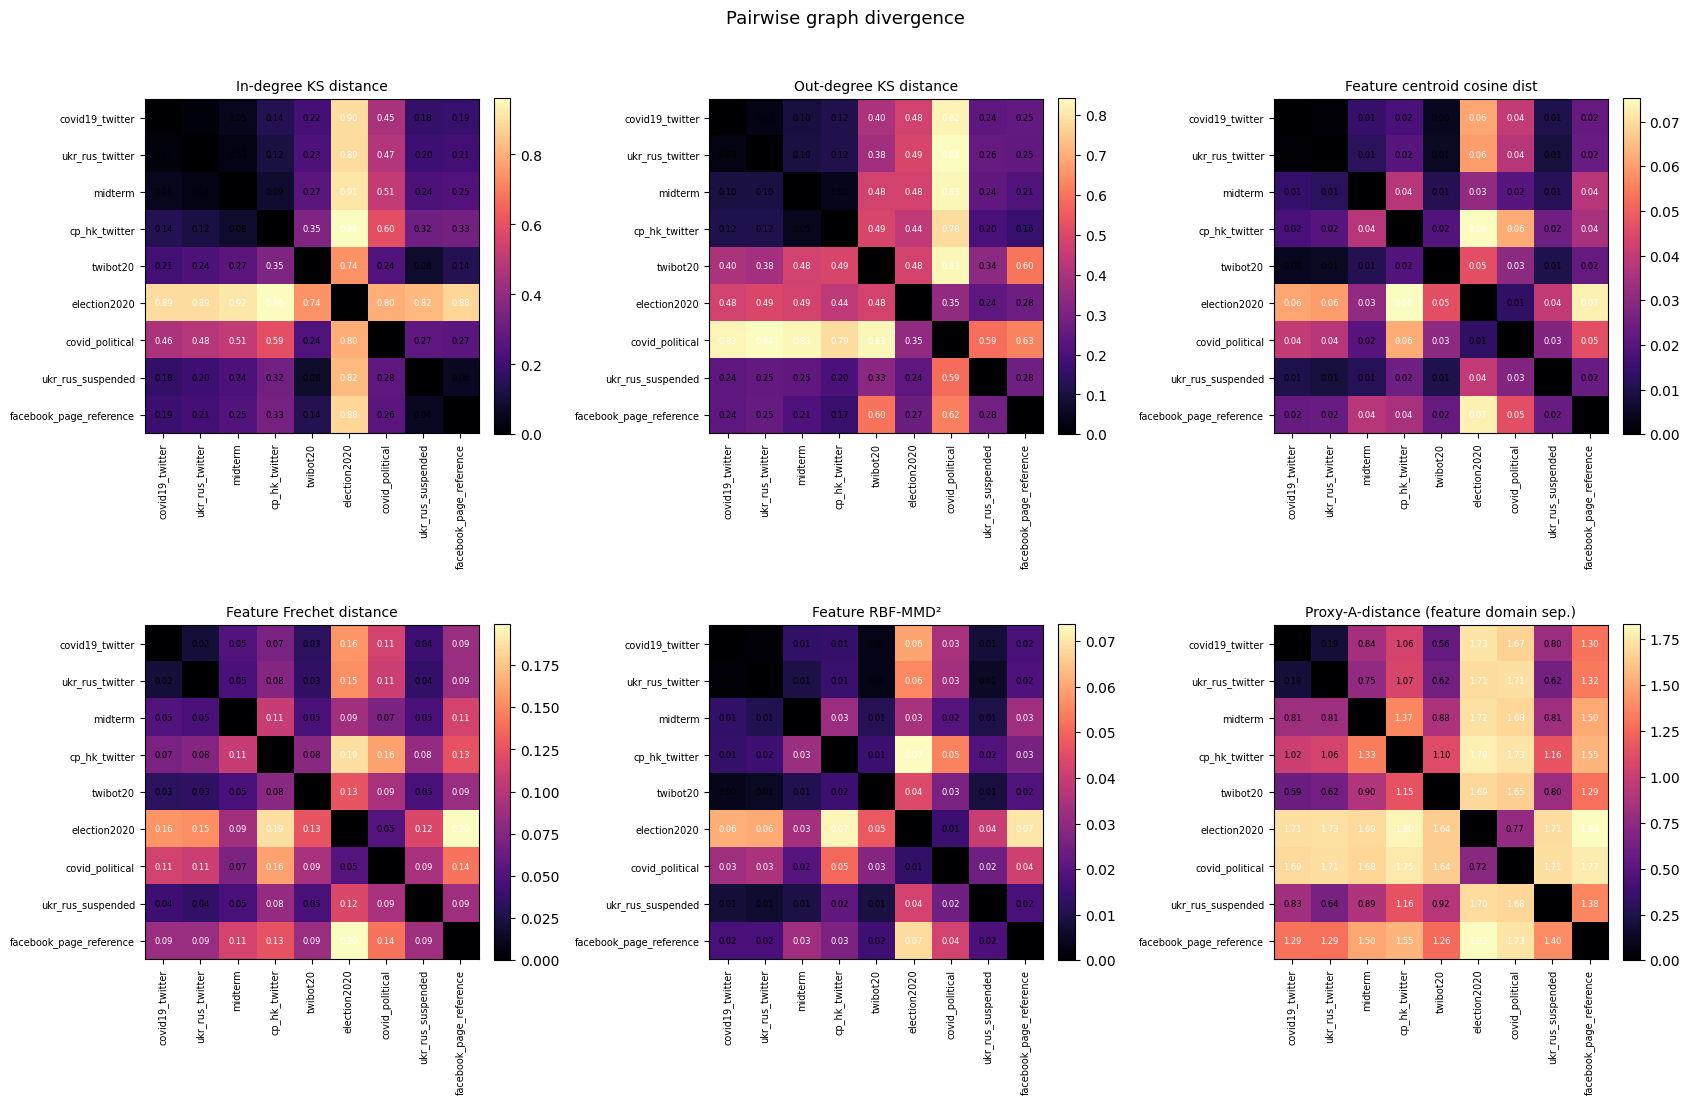

In [3]:
def heatmap(ax, M, title, cmap="magma"):
    A = np.array([[np.nan if v is None else v for v in row] for row in M], dtype=float)
    im = ax.imshow(A, cmap=cmap)
    ax.set_xticks(range(len(GRAPHS))); ax.set_yticks(range(len(GRAPHS)))
    ax.set_xticklabels(GRAPHS, rotation=90, fontsize=7)
    ax.set_yticklabels(GRAPHS, fontsize=7)
    ax.set_title(title, fontsize=10)
    for i in range(len(GRAPHS)):
        for j in range(len(GRAPHS)):
            if not np.isnan(A[i, j]):
                ax.text(j, i, f"{A[i, j]:.2f}", ha="center", va="center",
                        fontsize=6, color="white" if A[i, j] > np.nanmean(A) else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

PANELS = [
    ("indegree_ks", "In-degree KS distance"),
    ("outdegree_ks", "Out-degree KS distance"),
    ("feat_centroid_cosdist", "Feature centroid cosine dist"),
    ("feat_frechet", "Feature Frechet distance"),
    ("feat_mmd2", "Feature RBF-MMD²"),
    ("proxy_a_distance", "Proxy-A-distance (feature domain sep.)"),
]
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for ax, (key, title) in zip(axes.ravel(), PANELS):
    heatmap(ax, PW[key], title)
fig.suptitle("Pairwise graph divergence", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "pairwise_divergence_heatmaps.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. Degree distributions (topology marginals)

Complementary CDFs on log-log axes. Retweet graphs are hub-dominated, so the
in-degree tail is where structure diverges most.

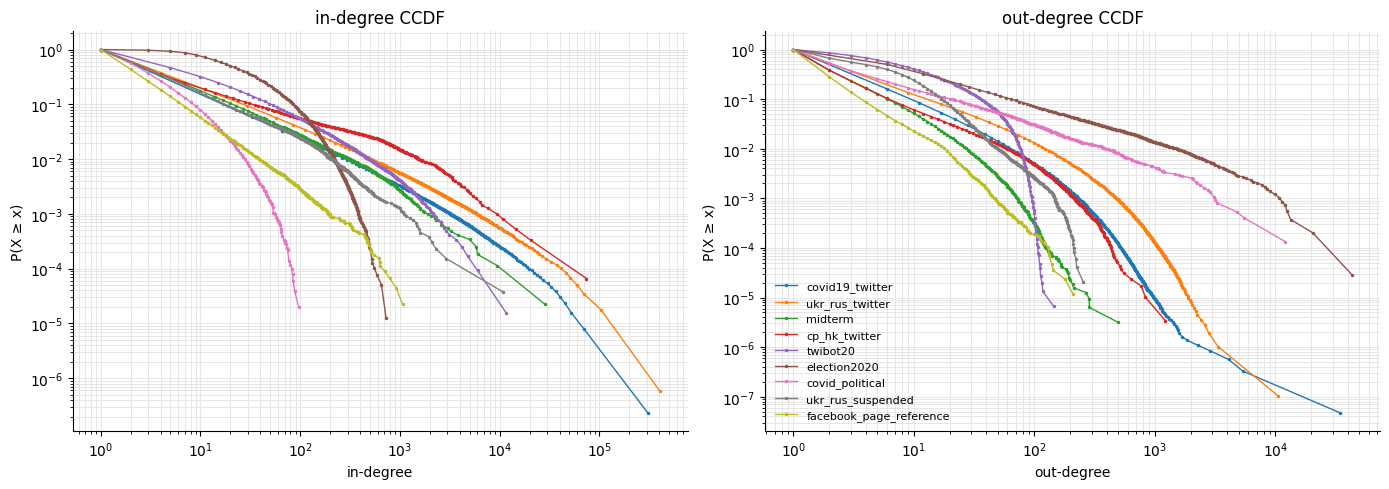

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, kind, label in [(axes[0], "indegree_ccdf", "in-degree"),
                        (axes[1], "outdegree_ccdf", "out-degree")]:
    for g in GRAPHS:
        c = PG[g][kind]
        ax.loglog(c["deg"], c["ccdf"], marker=".", ms=3, lw=1, label=g)
    ax.set_xlabel(f"{label}"); ax.set_ylabel("P(X ≥ x)")
    ax.set_title(f"{label} CCDF")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, which="both", color="#e2e2e2", lw=0.6)
axes[1].legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "degree_ccdf.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. Feature–structure coupling

The quantity a message-passing GNN actually exploits: do retweet edges connect
users with **similar bios** (feature homophily, vs. random-pair baseline), and
— where labels exist — similar **labels**?

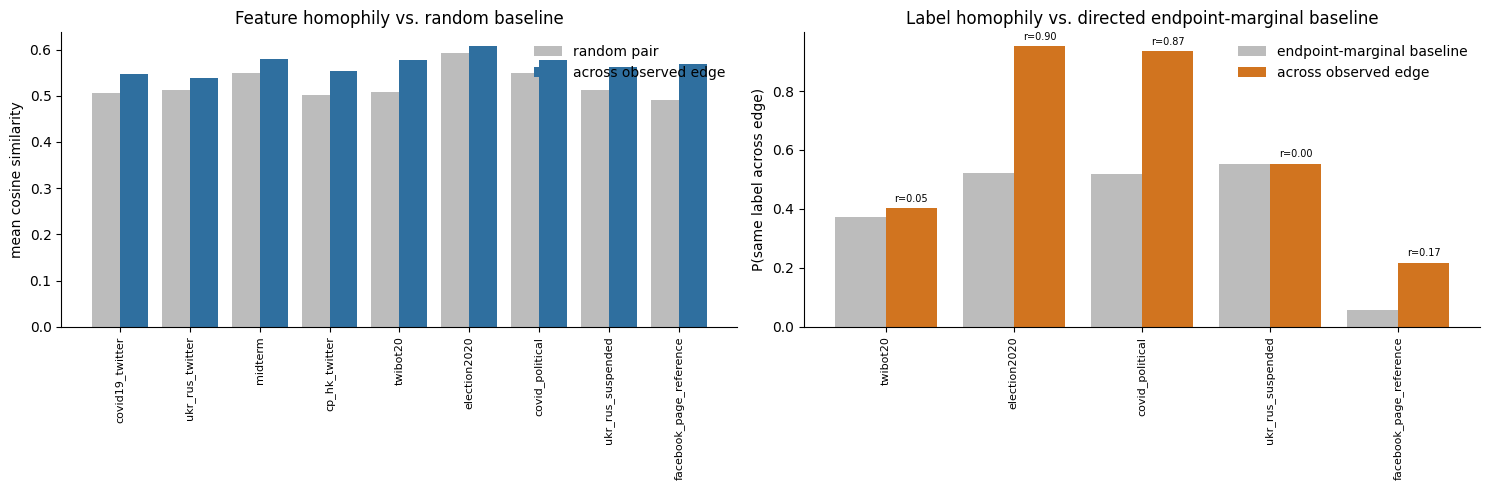

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(GRAPHS)); w = 0.4
fh = [PG[g].get("feature_homophily") or np.nan for g in GRAPHS]
fr = [PG[g].get("feature_homophily_random") or np.nan for g in GRAPHS]
ax1.bar(x - w/2, fr, w, label="random pair", color="#bcbcbc")
ax1.bar(x + w/2, fh, w, label="across observed edge", color="#2f6f9f")
ax1.set_xticks(x); ax1.set_xticklabels(GRAPHS, rotation=90, fontsize=8)
ax1.set_ylabel("mean cosine similarity"); ax1.set_title("Feature homophily vs. random baseline")
ax1.legend(frameon=False); ax1.spines[["top", "right"]].set_visible(False)

lab_g = [g for g in GRAPHS if PG[g].get("label_homophily") is not None]
lh = [PG[g]["label_homophily"] for g in lab_g]
label_random = []
label_newman = []
for g in lab_g:
    expected = PG[g].get("label_homophily_expected")
    if expected is None:  # compatibility with pre-Newman artifacts
        counts = np.array(list(PG[g]["class_balance"].values()), dtype=float)
        expected = float(((counts / counts.sum()) ** 2).sum())
    label_random.append(expected)
    label_newman.append(PG[g].get("label_assortativity_newman"))
lx = np.arange(len(lab_g)); lw = 0.4
ax2.bar(lx - lw/2, label_random, lw, color="#bcbcbc", label="endpoint-marginal baseline")
ax2.bar(lx + lw/2, lh, lw, color="#d1741f", label="across observed edge")
ax2.set_xticks(lx); ax2.set_xticklabels(lab_g, rotation=90, fontsize=8)
ax2.set_ylabel("P(same label across edge)"); ax2.set_title("Label homophily vs. directed endpoint-marginal baseline")
for i, (bar, r) in enumerate(zip(ax2.patches[len(lab_g):], label_newman)):
    if r is not None:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + .015, f"r={r:.2f}", ha="center", va="bottom", fontsize=7)
ax2.legend(frameon=False); ax2.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "coupling.png", dpi=140, bbox_inches="tight")
plt.show()

## Takeaways (8 graphs, full sweep)

**Two feature clusters, one of them an artifact.** The organic Twitter retweet
graphs — `covid19_twitter`, `ukr_rus_twitter`, `midterm`, `cp_hk_twitter`,
`twibot20` — sit close together in bio-embedding space (proxy-A-distance 0.2–1.3,
Frechet < 0.1). `election2020` and `covid_political` are far from everything else
(proxy-A ≈ 1.7) but close to **each other** (0.77). Those two are the political
label graphs built with a *different* embedding pipeline (meanpool pooling, **0%
missing bio** vs. 11–23% elsewhere), so their feature gap is largely a
**construction confound**, not domain shift — treat cross-pipeline feature
distances with caution.

**Topology splits the same way.** The big organic graphs share a heavy-tailed
in-degree (in-degree Gini ≈ 0.98), near-zero reciprocity, tiny strongly-connected
cores (SCC < 7%), and mild dis-assortativity. `election2020` is structurally an
outlier: in-degree KS ≈ 0.9 vs. all others, Gini only 0.54 (much flatter degree),
clustering 0.21, SCC ≈ 0 (near-DAG snapshot). `ukr_rus_suspended` has the highest
reciprocity (0.089) and `twibot20` is the only **assortative** graph (+0.19).

**Feature homophily is positive everywhere but modest** (lift over random pair
+0.02–0.07, strongest in `twibot20` 0.070 and `cp_hk` 0.052). Retweet edges do
connect more-similar bios than chance — the signal message passing transfers — and
its *consistency* across graphs is encouraging for feature-based transfer.

**Label assortativity depends entirely on the label.** Political leaning is strongly
assortative over retweet edges (`election2020`: raw homophily 0.952, Newman
$r=0.899$; `covid_political`: 0.936, $r=0.866$), so it can transfer through
message passing. Bot/human is only weakly assortative: `twibot20` has raw
homophily 0.401, but its directed edge-endpoint baseline is 0.372, giving
$r=0.047$ rather than heterophily. Only 1.65% of sampled edges have both endpoints
labeled, so this describes a small labeled subgraph. Suspended status is neutral
($r=0.004$); Facebook page category is modestly assortative ($r=0.168$).

**Reading it for a specific transfer.** For a source→target pair, close on all
three axes ⇒ expect clean transfer. A large in-degree KS or a homophily-sign flip
flags a structural mismatch; a large proxy-A-distance flags feature-covariate
shift — but first check it isn't just the meanpool-vs-zero-fill pipeline gap.
